# 01 — Setup & Distribution

Loads all pre-computed retrieval results, assigns decile columns, computes metrics, and shows how questions and corpus are distributed across popularity deciles.

## Setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))
from eval.shared_setup import *


✓ Boundaries loaded (UW: 1.0000…175763168.0000)
  computing approximation…
    loaded 50,575 rows
    computing recall@k / MRR…
    scanning corpus for doc lengths…
    matched 44,857 / 44,857 IDs
    cached → enriched_approximation.parquet
  computing bm25…
    loaded 50,575 rows
    computing recall@k / MRR…
    scanning corpus for doc lengths…
    matched 44,857 / 44,857 IDs
    cached → enriched_bm25.parquet

✓ shared_setup complete — 2 strategies ready
  Collection : wiki_full_bil
  Results dir: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/all_qa_8k_100
  Strategies : ['approximation', 'bm25']
  Decile mode: chunk_weighted


## Question & Corpus Distribution

  50,575 questions, 5,890,044 documents, 24,651,978 chunks


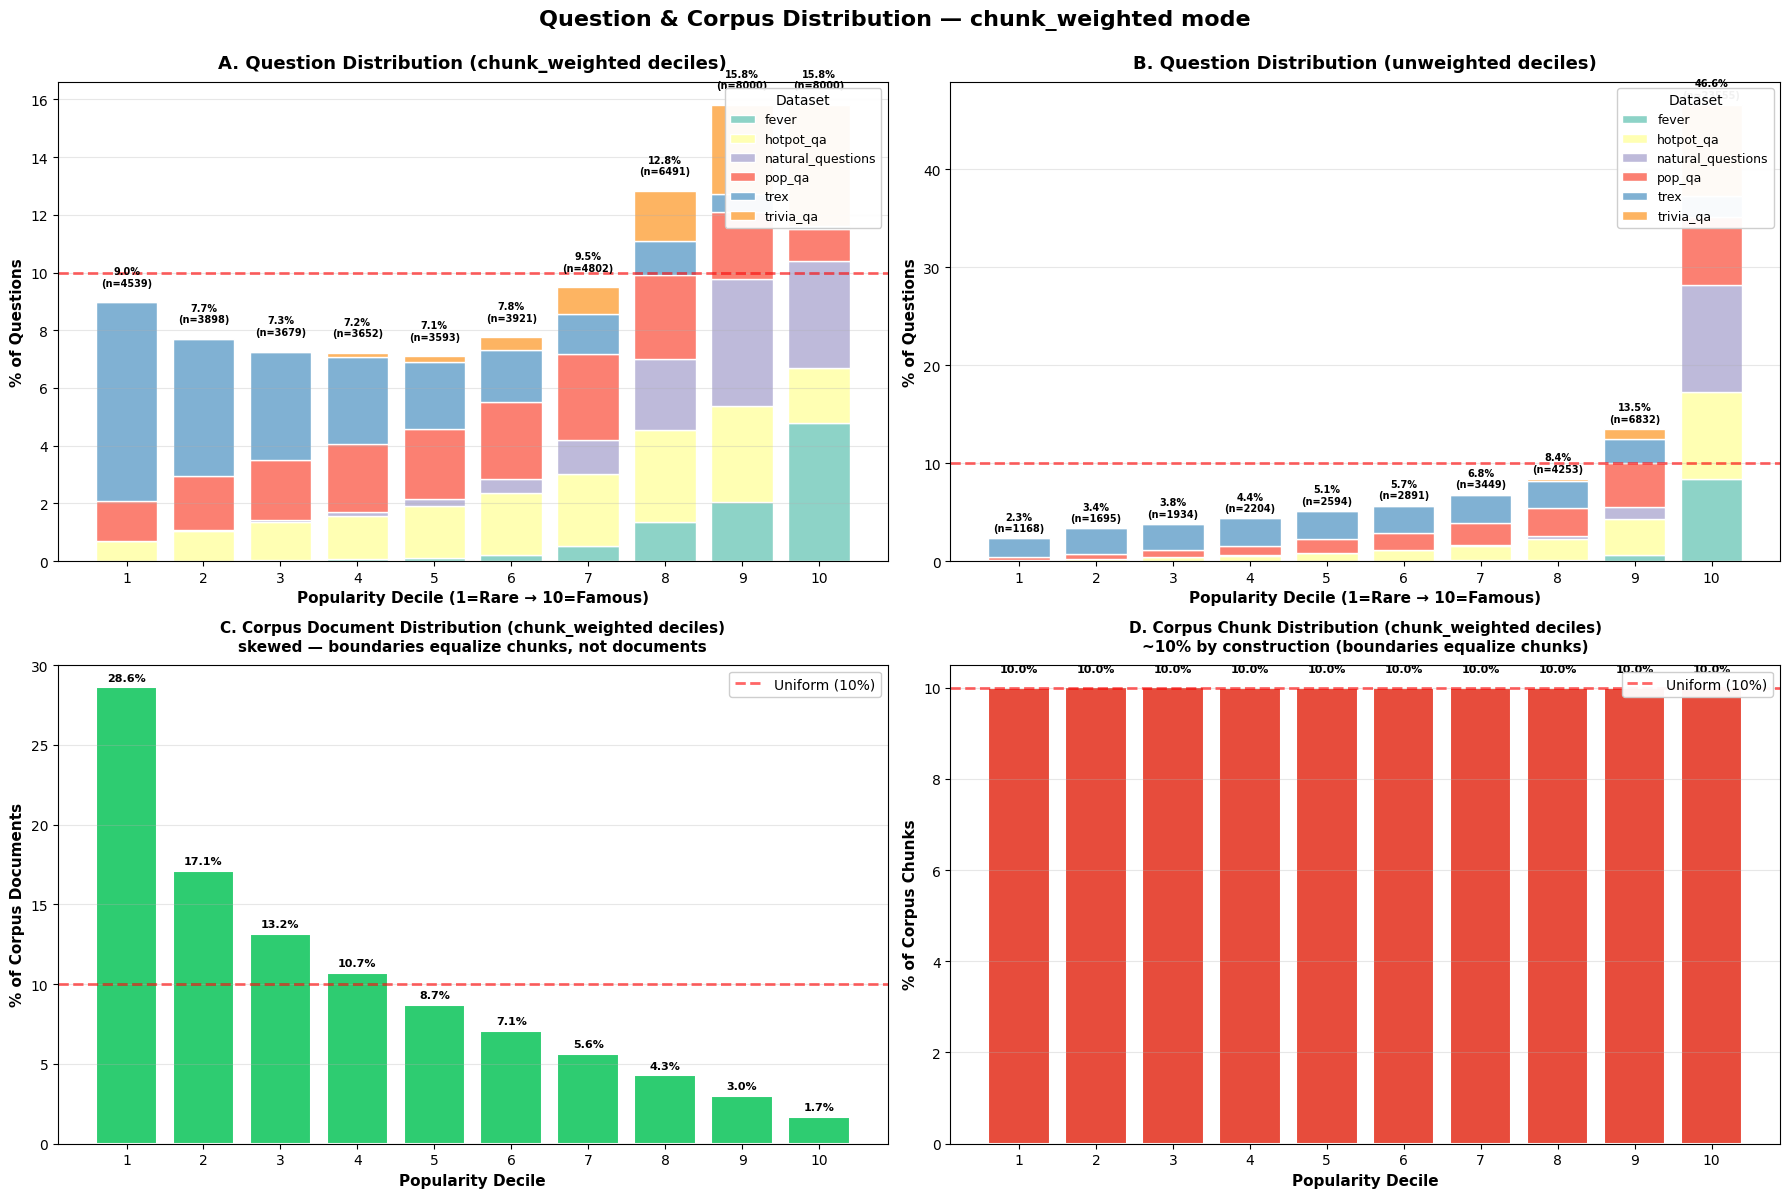

✓ Saved → distribution_overview.png


In [2]:
# ============================================================================
# Question & Corpus Distribution — Selected Decile Mode
# ============================================================================

from helpers.decile_utils import load_corpus_distributions, decile_col_for, boundaries_for

results_df = results_by_strategy[ALL_STRATEGIES[0]]
decile_col = decile_col_for(DECILE_MODE)
boundaries = boundaries_for(DECILE_MODE, boundaries_uw, boundaries_cw)

corpus_doc_pct   = (corpus_docs   / corpus_docs.sum())   * 100
corpus_chunk_pct = (corpus_chunks / corpus_chunks.sum()) * 100
print(f"  {len(results_df):,} questions, {corpus_docs.sum():,.0f} documents, {corpus_chunks.sum():,.0f} chunks")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- Panel A: Question Distribution (selected mode) ---
ax = axes[0, 0]
if "dataset" in results_df.columns:
    datasets = sorted(results_df["dataset"].dropna().unique())
    bottoms = np.zeros(10)
    colors = plt.cm.Set3.colors
    for i, ds in enumerate(datasets):
        ds_counts = results_df[results_df["dataset"] == ds][decile_col].value_counts().reindex(range(10), fill_value=0)
        ds_pcts = (ds_counts / len(results_df)) * 100
        ax.bar(np.arange(1, 11), ds_pcts.values, bottom=bottoms, color=colors[i % len(colors)],
               edgecolor='white', linewidth=1.0, label=ds)
        bottoms += ds_pcts.values
    for i, total in enumerate(bottoms):
        if total > 0.5:
            count = results_df[decile_col].value_counts().reindex(range(10), fill_value=0).iloc[i]
            ax.text(i + 1, total + 0.5, f'{total:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.95, title="Dataset")
else:
    q_counts = results_df[decile_col].value_counts().reindex(range(10), fill_value=0)
    q_pcts = (q_counts / len(results_df)) * 100
    ax.bar(np.arange(1, 11), q_pcts.values, color='#3498db', edgecolor='white', linewidth=1.5)
ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
ax.set_xlabel("Popularity Decile (1=Rare → 10=Famous)", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Questions", fontsize=11, fontweight='bold')
ax.set_title(f"A. Question Distribution ({DECILE_MODE} deciles)", fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

# --- Panel B: Question Distribution (other mode — for comparison) ---
other_mode = "unweighted" if DECILE_MODE == "chunk_weighted" else "chunk_weighted"
other_col  = decile_col_for(other_mode)
ax = axes[0, 1]
if "dataset" in results_df.columns:
    bottoms = np.zeros(10)
    for i, ds in enumerate(datasets):
        ds_counts = results_df[results_df["dataset"] == ds][other_col].value_counts().reindex(range(10), fill_value=0)
        ds_pcts = (ds_counts / len(results_df)) * 100
        ax.bar(np.arange(1, 11), ds_pcts.values, bottom=bottoms, color=colors[i % len(colors)],
               edgecolor='white', linewidth=1.0, label=ds)
        bottoms += ds_pcts.values
    for i, total in enumerate(bottoms):
        if total > 0.5:
            count = results_df[other_col].value_counts().reindex(range(10), fill_value=0).iloc[i]
            ax.text(i + 1, total + 0.5, f'{total:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.95, title="Dataset")
ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
ax.set_xlabel("Popularity Decile (1=Rare → 10=Famous)", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Questions", fontsize=11, fontweight='bold')
ax.set_title(f"B. Question Distribution ({other_mode} deciles)", fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

# --- Panel C: Corpus DOCUMENT Distribution ---
ax = axes[1, 0]
ax.bar(np.arange(1, 11), corpus_doc_pct, color='#2ecc71', edgecolor='white', linewidth=1.5)
for i, val in enumerate(corpus_doc_pct):
    if val > 0.5:
        ax.text(i + 1, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
c_note = "~10% by construction (boundaries equalize documents)" if DECILE_MODE == "unweighted" else "skewed — boundaries equalize chunks, not documents"
ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Corpus Documents", fontsize=11, fontweight='bold')
ax.set_title(f"C. Corpus Document Distribution ({DECILE_MODE} deciles)\n{c_note}", fontsize=11, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

# --- Panel D: Corpus CHUNK Distribution ---
ax = axes[1, 1]
ax.bar(np.arange(1, 11), corpus_chunk_pct, color='#e74c3c', edgecolor='white', linewidth=1.5)
for i, val in enumerate(corpus_chunk_pct):
    if val > 0.5:
        ax.text(i + 1, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
d_note = "~10% by construction (boundaries equalize chunks)" if DECILE_MODE == "chunk_weighted" else "skewed — boundaries equalize documents, not chunks"
ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Corpus Chunks", fontsize=11, fontweight='bold')
ax.set_title(f"D. Corpus Chunk Distribution ({DECILE_MODE} deciles)\n{d_note}", fontsize=11, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

plt.suptitle(f"Question & Corpus Distribution — {DECILE_MODE} mode", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "distribution_overview.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved → distribution_overview.png")
